In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load prepared Duplicate QC dataset
df = pd.read_csv("../data/processed/duplicates_model.csv")

df.head()


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_DUP_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_DUP_VALUE,UNIT_CODE
0,2021-05-10 11:39:33.000000,TA,3.378640,2.185365,12.5,2.782003,1.193275,42.89,Pass,15.0,MG_KG
1,2021-05-10 11:39:33.000000,TA,-0.746270,0.801886,12.5,0.027808,1.548156,5567.32,Pass,15.0,MG_KG
2,2021-05-10 11:39:33.000000,TA,1.879069,1.260273,12.5,1.569671,0.618796,39.42,Pass,15.0,MG_KG
3,2021-05-10 11:38:57.000000,TA,-3.129188,-2.010870,12.5,-2.570029,1.118317,-43.51,Pass,15.0,MG_KG
4,2021-05-10 11:38:57.000000,TA,-2.185186,-3.709679,12.5,-2.947432,1.524493,-51.72,Pass,15.0,MG_KG


In [3]:
# Historical reference population
accepted_statuses = ["Pass", "IgnoreFailure"]

df_reference = df[
    (df["RPD"] > 0) &
    (df["PRECISION_STATUS"].isin(accepted_statuses)) &
    (df["MEAN_CONC"] > 0)
].copy()


In [4]:
# Analytes selected for the historical reference model
MODEL_ANALYTES = [
    "MN",
    "MG",
    "RB",
    "CO",
    "ZN"
]

# Select pilot analyte for model development
PILOT_ANALYTE = "MN"

if PILOT_ANALYTE not in MODEL_ANALYTES:
    raise ValueError(f"{PILOT_ANALYTE} is not included in MODEL_ANALYTES")

df_pilot = (
    df_reference[
        df_reference["ANALYTE_CODE"] == PILOT_ANALYTE
    ]
    .copy()
    .sort_values("MEAN_CONC")
)

print(f"Model analytes: {', '.join(MODEL_ANALYTES)}")
print(f"Pilot analyte: {PILOT_ANALYTE}")
print(f"Observations: {len(df_pilot):,}")
print(
    f"Concentration range: "
    f"{df_pilot['MEAN_CONC'].min():,.3f} "
    f"to {df_pilot['MEAN_CONC'].max():,.3f}"
)

df_pilot.head()


Model analytes: MN, MG, RB, CO, ZN
Pilot analyte: MN
Observations: 123
Concentration range: 36.924 to 16,829.724


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_DUP_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_DUP_VALUE,UNIT_CODE
4279,2020-11-05 10:45:28.000000,MN,76.152000,-2.304000,5.0,36.924000,78.456000,212.48,IgnoreFailure,15.0,MG_KG
4776,2020-07-17 11:34:19.000000,MN,111.280000,110.354146,5.0,110.817073,0.925854,0.84,Pass,15.0,MG_KG
3786,2020-11-24 10:25:22.000000,MN,150.573529,149.668269,5.0,150.120899,0.905260,0.60,Pass,15.0,MG_KG
4752,2020-07-21 09:14:04.000000,MN,158.148187,148.549541,5.0,153.348864,9.598645,6.26,Pass,15.0,MG_KG
3033,2021-02-18 13:47:24.000000,MN,185.394652,150.795789,5.0,168.095221,34.598863,20.58,IgnoreFailure,15.0,MG_KG


In [5]:
import statsmodels.formula.api as smf
from patsy import bs

# Log-transform concentration for the selected pilot analyte
df_pilot["LOG_MEAN_CONC"] = np.log10(
    df_pilot["MEAN_CONC"]
)

# Quantiles used by the historical reference model
quantiles = [0.25, 0.50, 0.75, 0.95]


In [6]:
# Fit nonlinear quantile regression models using B-splines
spline_models = {}

for q in quantiles:
    spline_models[q] = smf.quantreg(
        "RPD ~ bs(LOG_MEAN_CONC, df=4, degree=3)",
        df_pilot
    ).fit(q=q)

print("Spline quantile models fitted:")
for q in quantiles:
    print(f"Q{int(q * 100):02d}")
    

Spline quantile models fitted:
Q25
Q50
Q75
Q95


In [7]:
# Generate concentration values across the observed pilot analyte range
x_grid = np.linspace(
    df_pilot["LOG_MEAN_CONC"].min(),
    df_pilot["LOG_MEAN_CONC"].max(),
    300
)

# Create prediction grid and retain analyte identity
spline_prediction_df = pd.DataFrame({
    "ANALYTE_CODE": PILOT_ANALYTE,
    "LOG_MEAN_CONC": x_grid
})

# Convert back to original concentration for plotting
spline_prediction_df["MEAN_CONC"] = (
    10 ** spline_prediction_df["LOG_MEAN_CONC"]
)

# Generate fitted spline quantile values
for q in quantiles:
    spline_prediction_df[f"Q{int(q * 100):02d}"] = (
        spline_models[q].predict(spline_prediction_df)
    )

spline_prediction_df.head()


,ANALYTE_CODE,LOG_MEAN_CONC,MEAN_CONC,Q25,Q50,Q75,Q95
0,MN,1.567309,36.924000,99.596705,212.480000,212.480000,212.480000
1,MN,1.576201,37.687814,97.064620,207.150410,207.165359,207.512046
2,MN,1.585093,38.467428,94.575235,201.909989,201.940130,202.624894
3,MN,1.593985,39.263169,92.128195,196.757998,196.803573,197.817887
4,MN,1.602878,40.075371,89.723145,191.693703,191.754946,193.090371


In [8]:
# Fit spline quantile regression models for the selected pilot analyte

# Validate that modelling inputs are available
required_columns = ["RPD", "LOG_MEAN_CONC"]

missing_columns = [
    col for col in required_columns
    if col not in df_pilot.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required modelling columns: {missing_columns}"
    )

# Fit one spline quantile regression model for each required quantile
spline_models = {}

for q in quantiles:
    spline_models[q] = smf.quantreg(
        "RPD ~ bs(LOG_MEAN_CONC, df=4, degree=3)",
        df_pilot
    ).fit(q=q)

# Confirm fitted models
print(f"Pilot analyte: {PILOT_ANALYTE}")
print(f"Observations used: {len(df_pilot):,}")
print(
    "Fitted quantiles: "
    + ", ".join(f"Q{int(q * 100):02d}" for q in quantiles)
)


Pilot analyte: MN
Observations used: 123
Fitted quantiles: Q25, Q50, Q75, Q95


In [11]:
# Corporate / professional chart palette
OBS_COLOUR = "#5B9BD5"       # historical observations
QUANTILE_COLOUR = "#5B6573"  # Q1 and Q3
MEDIAN_COLOUR = "#1F4E79"    # median - dark corporate blue
P95_COLOUR = "#A33A3A"       # muted red - exception / warning threshold
IQR_COLOUR = "#AFC6DB"       # subtle blue-grey shading


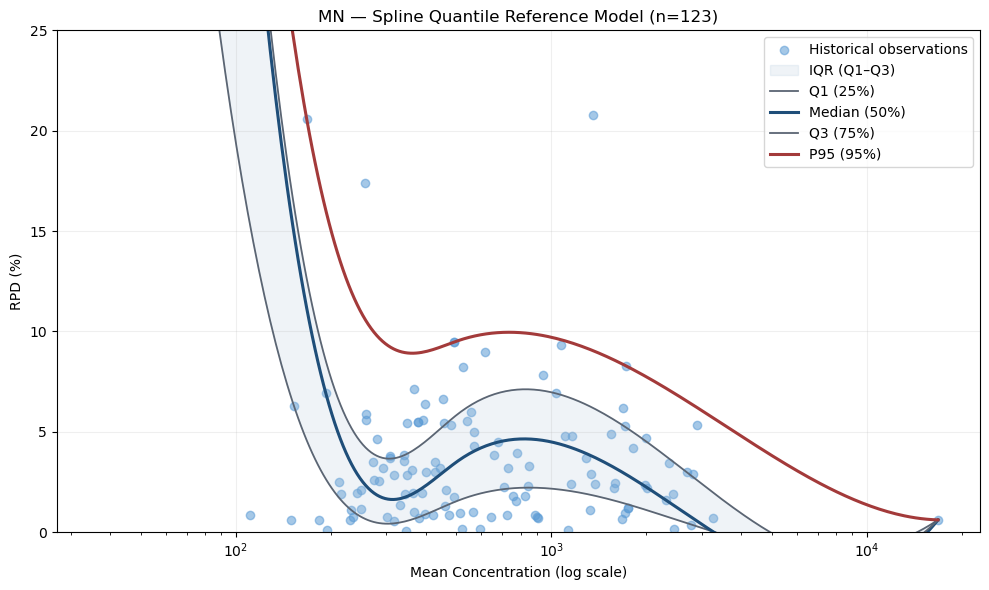

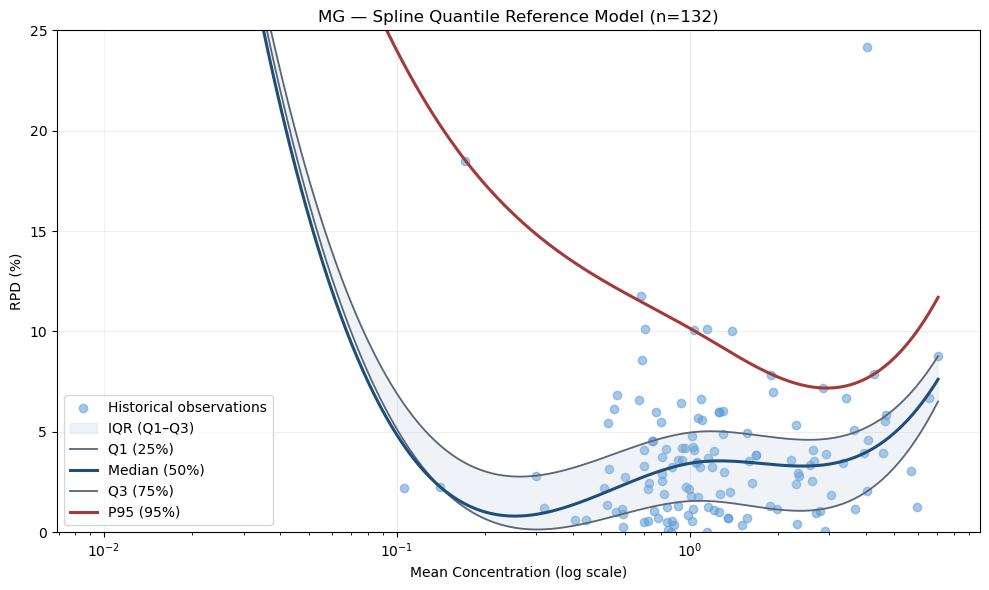

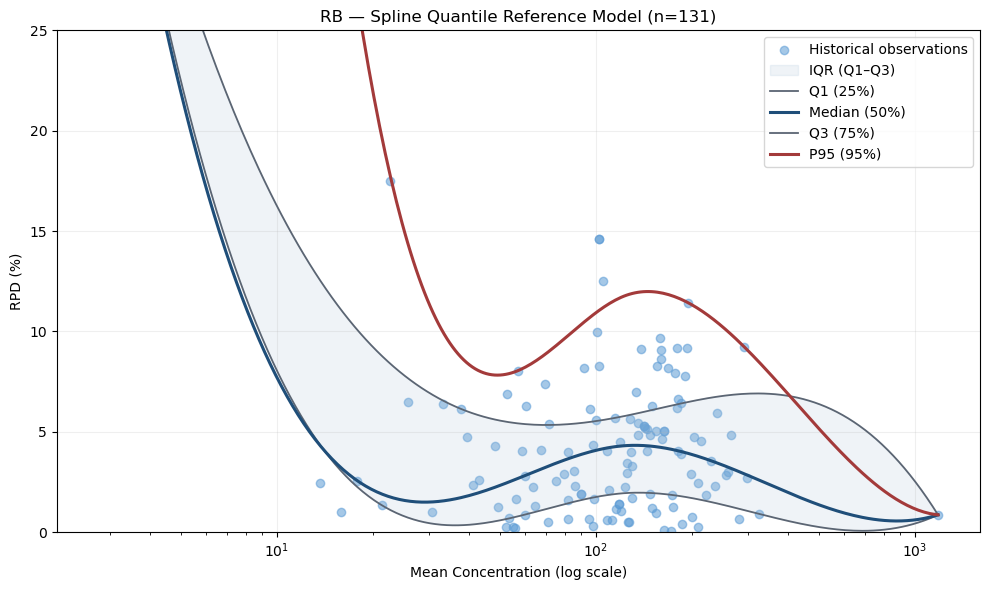

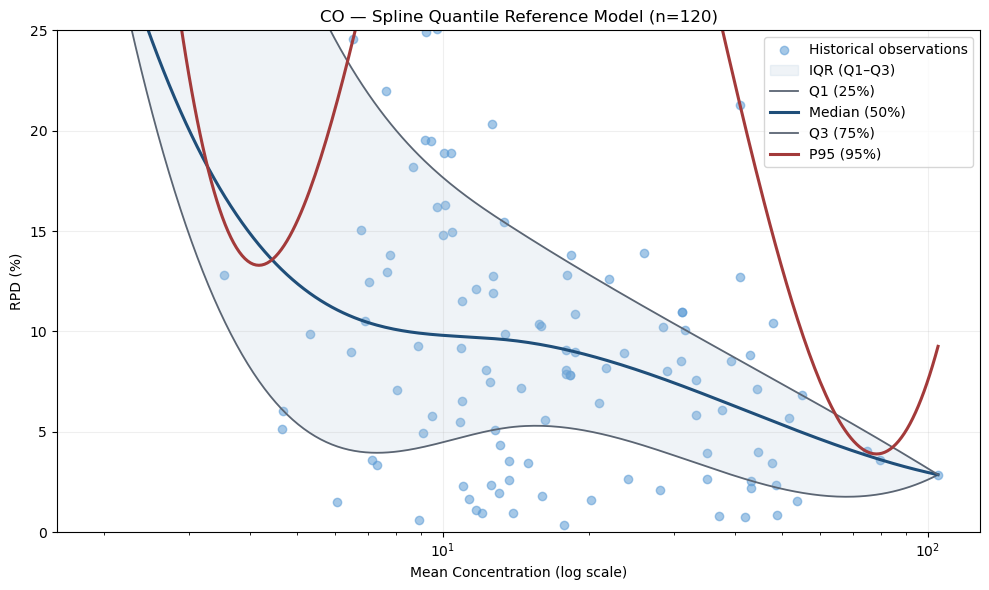

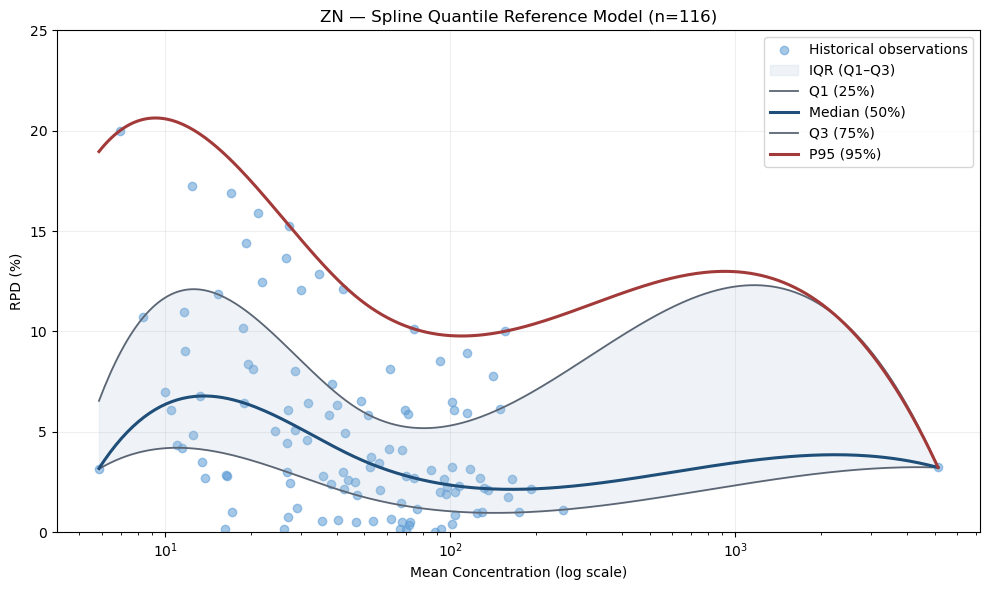

In [12]:
# Plot spline quantile reference model for each selected analyte

for analyte in MODEL_ANALYTES:

    # Select historical reference observations for this analyte
    df_plot = (
        df_reference[
            df_reference["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    # Log-transform concentration
    df_plot["LOG_MEAN_CONC"] = np.log10(
        df_plot["MEAN_CONC"]
    )

    # Fit spline quantile models
    plot_models = {}

    for q in quantiles:
        plot_models[q] = smf.quantreg(
            "RPD ~ bs(LOG_MEAN_CONC, df=4, degree=3)",
            df_plot
        ).fit(q=q)

    # Create prediction grid across observed concentration range
    x_grid = np.linspace(
        df_plot["LOG_MEAN_CONC"].min(),
        df_plot["LOG_MEAN_CONC"].max(),
        300
    )

    pred_plot = pd.DataFrame({
        "ANALYTE_CODE": analyte,
        "LOG_MEAN_CONC": x_grid
    })

    # Convert prediction grid back to original concentration scale
    pred_plot["MEAN_CONC"] = (
        10 ** pred_plot["LOG_MEAN_CONC"]
    )

    # Generate fitted quantile predictions
    for q in quantiles:
        pred_plot[f"Q{int(q * 100):02d}"] = (
            plot_models[q].predict(pred_plot)
        )

    # ---------------------------------------------------------
    # Plot reference model
    # ---------------------------------------------------------

    plt.figure(figsize=(10, 6))

    # Historical observations
    plt.scatter(
        df_plot["MEAN_CONC"],
        df_plot["RPD"],
        alpha=0.55,
        color=OBS_COLOUR,
        label="Historical observations"
    )

    # Interquartile reference band
    plt.fill_between(
        pred_plot["MEAN_CONC"],
        pred_plot["Q25"],
        pred_plot["Q75"],
        color=IQR_COLOUR,
        alpha=0.20,
        label="IQR (Q1–Q3)"
    )

    # Q1
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q25"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        label="Q1 (25%)"
    )

    # Median
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q50"],
        color=MEDIAN_COLOUR,
        linewidth=2.2,
        label="Median (50%)"
    )

    # Q3
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q75"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        label="Q3 (75%)"
    )

    # P95 upper reference
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q95"],
        color=P95_COLOUR,
        linewidth=2.2,
        label="P95 (95%)"
    )

    # Chart formatting
    plt.xscale("log")
    plt.ylim(0, 25)

    plt.xlabel("Mean Concentration (log scale)")
    plt.ylabel("RPD (%)")

    plt.title(
        f"{analyte} — Spline Quantile Reference Model "
        f"(n={len(df_plot):,})"
    )

    plt.legend()
    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()
    